Regiones y fronteras

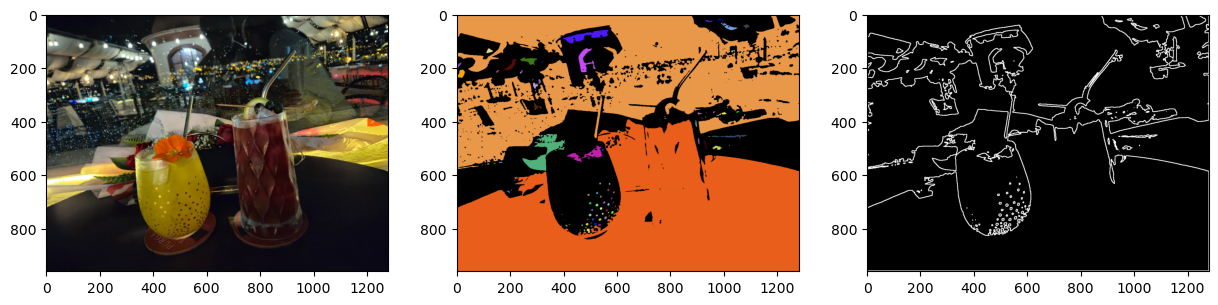

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img= cv2.imread('colores.jpeg')
#cv2.imshow('colores',img)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# combinamos tecnicas
blur = cv2.GaussianBlur(gray, (7, 7), 0)
_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
# Encontrar regiones
num_labels, label= cv2.connectedComponents(binary)
# identificar por colores
color=np.random.randint(0,255,size=(num_labels,3),dtype=np.uint8)
# fondo negro
color[0]=[0,0,0]
# vamos a colorear
colorear=color[label]

#encontrar las fronteras
contornos, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contorno_fin=cv2.drawContours(np.zeros_like(gray), contornos,-1,255,2)

plt.figure(figsize=(15,5))
plt.subplot(131)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.subplot(132)
plt.imshow(colorear)
plt.subplot(133)
plt.imshow(contorno_fin,cmap='gray')
plt.show()


Conteo

Número de elementos en la imagen: 328


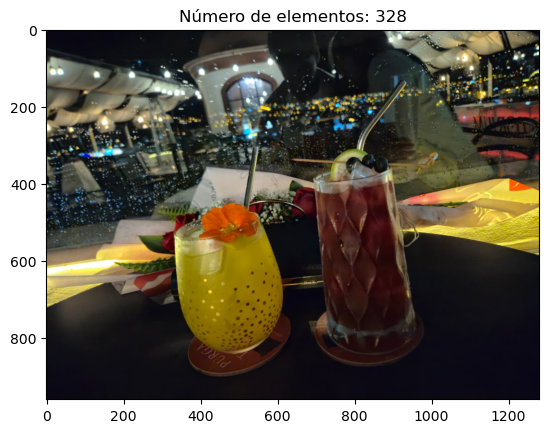

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def contar_elementos(imagen):
    # Convertir a escala de grises
    gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    
    # Aplicar umbral para binarizar la imagen
    _, binary = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY_INV )
    
    # Etiquetar las regiones conectadas
    etiquetas = measure.label(binary, connectivity=2) # cuando se trabaja con dos dimensiones, connectivity=2 considera las conexiones diagonales 
    #si trabajamos con 1 dimensión, connectivity=1 considera solo las conexiones horizontales y verticales.
    
    # Contar el número de elementos (regiones etiquetadas)
    num_elementos = np.max(etiquetas)
    
    return num_elementos

# Cargar la imagen
imagen = cv2.imread('colores.jpeg')
# Contar los elementos en la imagen
conteo=contar_elementos(imagen)
num_elementos = contar_elementos(imagen)
print(f'Número de elementos en la imagen: {num_elementos}') 

plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.title(f'Número de elementos: {num_elementos}')
plt.show()





Union actividad  regiones fronteras y conteo

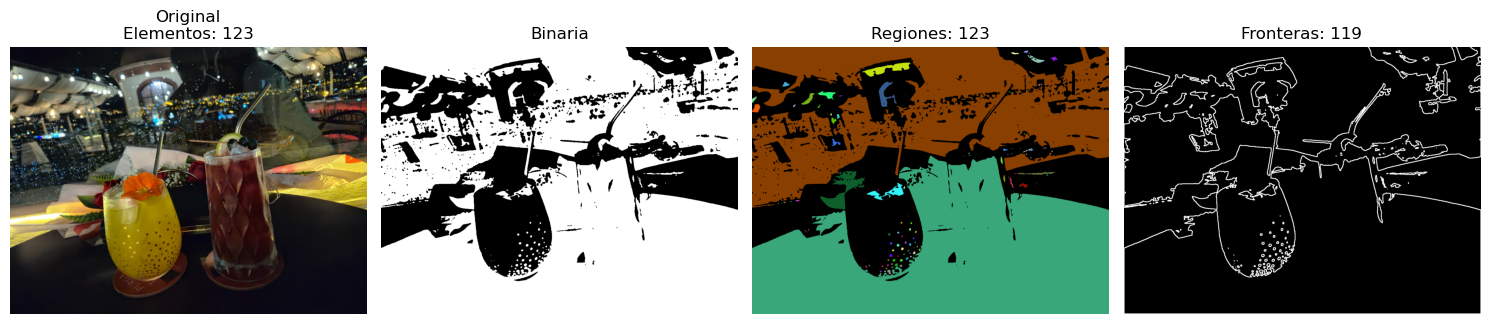

Número de elementos en la imagen: 123


In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

img = cv2.imread("colores.jpeg")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (7, 7), 0)

# binary
_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Regiones conectadas
num_labels, labels = cv2.connectedComponents(binary)

# Colorear regiones
color = np.random.randint(0, 255, size=(num_labels, 3), dtype=np.uint8)
color[0] = [0, 0, 0] 
colorear = color[labels]

# Contar elementos
etiquetas = measure.label(binary, connectivity=2)
num_elementos = np.max(etiquetas)

# Encontrar fronteras
contornos, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contorno_fin = cv2.drawContours(np.zeros_like(gray), contornos, -1, 255, 2)

# Mostrar resultados
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f"Original\nElementos: {num_elementos}")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(binary, cmap="gray")
plt.title("Binaria")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(colorear)
plt.title(f"Regiones: {num_labels - 1}")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(contorno_fin, cmap="gray")
plt.title(f"Fronteras: {len(contornos)}")
plt.axis("off")

plt.tight_layout()
plt.show()

print(f"Número de elementos en la imagen: {num_elementos}")